In [79]:
# ============================================================
# Mortgage Rate Optimization (Freddie Mac - Prepared Dataset)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

np.random.seed(42)



In [80]:
# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("Prepared_Dataset.csv")

print("Initial shape:", df.shape)


Initial shape: (148938, 39)


In [81]:
import pandas as pd

pmms_raw = pd.read_excel("historicalweeklydata.xlsx", sheet_name="Full History", header=7)

In [82]:
# Rename columns — the file has Date, 30-yr rate, fees, 15-yr rate, fees
pmms_raw.columns = ["date", "rate_30yr", "fees_30yr", "rate_15yr", "fees_15yr"] + \
                   list(pmms_raw.columns[5:])

# Keep only what we need
pmms = pmms_raw[["date", "rate_30yr"]].copy()
pmms = pmms.dropna(subset=["date", "rate_30yr"])

# Parse date
pmms["date"] = pd.to_datetime(pmms["date"])
pmms["pmms_year"] = pmms["date"].dt.year
pmms["pmms_month"] = pmms["date"].dt.month

# Convert rate from percentage to decimal (e.g. 6.5 → 0.065)
pmms["rate_30yr"] = pmms["rate_30yr"].astype(float)
pmms["rm"] = pmms["rate_30yr"] / 100

# Compute monthly average (there are ~4 weekly readings per month)
pmms_monthly = (
    pmms.groupby(["pmms_year", "pmms_month"])["rm"]
    .mean()
    .reset_index()
    .rename(columns={"pmms_year": "year", "pmms_month": "month"})
)

print(pmms_monthly.head(10))

   year  month        rm
0  1971      4  0.073050
1  1971      5  0.074250
2  1971      6  0.075300
3  1971      7  0.076040
4  1971      8  0.076975
5  1971      9  0.076875
6  1971     10  0.076280
7  1971     11  0.075500
8  1971     12  0.074800
9  1972      1  0.074375


In [83]:
# Parse from the clean date column instead
df["parsed_date"] = pd.to_datetime(df["Parsed_FirstPaymentDate"], errors="coerce")
df["fp_year"] = df["parsed_date"].dt.year.astype(int)
df["fp_month"] = df["parsed_date"].dt.month.astype(int)

# Verify it looks right
print(df[["Parsed_FirstPaymentDate", "fp_year", "fp_month"]].head(5))

  Parsed_FirstPaymentDate  fp_year  fp_month
0              1999-02-01     1999         2
1              1999-02-01     1999         2
2              1999-02-01     1999         2
3              1999-02-01     1999         2
4              1999-02-01     1999         2


In [84]:
pmms_monthly["year"] = pmms_monthly["year"].astype(int)
pmms_monthly["month"] = pmms_monthly["month"].astype(int)

df = df.merge(
    pmms_monthly,
    left_on=["fp_year", "fp_month"],
    right_on=["year", "month"],
    how="left"
)

print("Matched:", df["rm"].notna().sum())
print("Unmatched:", df["rm"].isna().sum())

df["rm"] = df["rm"].fillna(0.045)

print(df[["Parsed_FirstPaymentDate", "fp_year", "fp_month", "rm"]].head(10))

Matched: 148938
Unmatched: 0
  Parsed_FirstPaymentDate  fp_year  fp_month        rm
0              1999-02-01     1999         2  0.068075
1              1999-02-01     1999         2  0.068075
2              1999-02-01     1999         2  0.068075
3              1999-02-01     1999         2  0.068075
4              1999-02-01     1999         2  0.068075
5              1999-02-01     1999         2  0.068075
6              1999-02-01     1999         2  0.068075
7              1999-02-01     1999         2  0.068075
8              1999-02-01     1999         2  0.068075
9              1999-02-01     1999         2  0.068075


In [85]:
# ------------------------------------------------------------
# 2. BASIC CLEANING
# ------------------------------------------------------------

df = df.dropna()

df = df[
    (df["CreditScore"].between(500, 850)) &
    (df["LTV"].between(10, 100)) &
    (df["DTI"].between(0, 60)) &
    (df["OrigUPB"] > 0) &
    (df["OrigInterestRate"].between(1, 10))
]

print("Clean shape:", df.shape)

Clean shape: (148046, 45)


In [86]:
# ------------------------------------------------------------
# 3. TARGET VARIABLE (SERIOUS DELINQUENCY / DEFAULT)
# ------------------------------------------------------------

df["default_flag"] = (df["MonthsDelinquent"] >= 3).astype(int)


# ------------------------------------------------------------
# 4. FEATURE ENGINEERING
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# ---- Mild Filtering ----

df = df[
    (df["CreditScore"] > 550) &
    (df["LTV"] < 95) &
    (df["DTI"] < 55) &
    (df["OrigUPB"] > 0)
].copy()

print("Default Rate:", round(df["default_flag"].mean(), 4))


# ---- Normalized Continuous Features ----

df["credit_z"] = (df["CreditScore"] - 720) / 50
df["dti_z"] = (df["DTI"] - 30) / 10
df["ltv_z"] = (df["LTV"] - 80) / 10
df["rate_z"] = (df["OrigInterestRate"] - 4) / 1


# ---- Borrower / Loan Features ----

df["first_time_flag"] = (
    df["IsFirstTimeHomebuyer"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
    .fillna(0)
    .astype(int)
)

df["log_upb"] = np.log(df["OrigUPB"])


# ---- Nonlinear Features ----

df["ltv_sq"] = df["ltv_z"] ** 2
df["dti_sq"] = df["dti_z"] ** 2
df["credit_sq"] = df["credit_z"] ** 2


# ---- Interaction Features ----

df["credit_ltv"] = df["credit_z"] * df["ltv_z"]
df["credit_dti"] = df["credit_z"] * df["dti_z"]
df["ltv_dti"] = df["ltv_z"] * df["dti_z"]

# NEW: repayment features (you added these but didn’t use them)
df["log_repay"] = np.log1p(df["MonthsInRepayment"])
df["repay_ltv"] = df["MonthsInRepayment"] * df["ltv_z"]


# ---- One-Hot Encode Range Features ----

df = pd.get_dummies(df, columns=["LTV_range", "Credit_range"], drop_first=True)

range_features = [
    col for col in df.columns
    if col.startswith("LTV_range_") or col.startswith("Credit_range_")
]


# ---- NEW: One-Hot Encode Additional Categorical Features ----

cat_cols = ["ServicerName", "LoanPurpose", "PropertyState", "PropertyType"]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

cat_features = [
    col for col in df.columns
    if any(prefix in col for prefix in [
        "ServicerName_",
        "LoanPurpose_",
        "PropertyState_",
        "PropertyType_"
    ])
]


# ------------------------------------------------------------
# 5. DEFAULT MODEL (XGBOOST + RANDOMIZED SEARCH CV)
# ------------------------------------------------------------

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

features = [
    "credit_z",
    "dti_z",
    "ltv_z",
    "log_upb",
    "rate_z",
    "first_time_flag",
    "ltv_sq",
    "dti_sq",
    "credit_sq",
    "credit_ltv",
    "credit_dti",
    "ltv_dti",
    "log_repay",        # now included
    "repay_ltv"         # now included
] + range_features + cat_features

X = df[features]
y = df["default_flag"]


# ---- Train/Test Split ----

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# ---- Class Imbalance ----

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()


# ---- Base Model ----

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)


# ---- Hyperparameter Space ----

param_dist = {
    "n_estimators": [500, 700, 900],
    "max_depth": [4, 5],
    "learning_rate": [0.005, 0.01, 0.02],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.05, 0.1],
    "reg_lambda": [1, 1.5, 2],
    "reg_alpha": [0, 0.5, 1]
}


# ---- Randomized Search ----

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ---- Best Model ----

USE_TUNED = True

if USE_TUNED:
    model_default = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        subsample=0.7,
        colsample_bytree=0.8,
        n_estimators=900,
        max_depth=4,
        learning_rate=0.01,
        min_child_weight=1,
        gamma=0.05,
        reg_lambda=2,
        reg_alpha=1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
else:
    random_search.fit(X_train, y_train)
    model_default = random_search.best_estimator_
    print("Best Params:", random_search.best_params_)

# ---- Train Final Model ----
model_default.fit(X_train, y_train)

# ---- Evaluation ----
pd_test = model_default.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pd_test)

print("Tuned Model AUC:", round(auc, 4))

Default Rate: 0.1445
Tuned Model AUC: 0.7867


In [87]:
# ------------------------------------------------------------
# 6. ACCEPTANCE MODEL (SYNTHETIC)
# ------------------------------------------------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def acceptance_prob(row, r):
    credit_z = (row["CreditScore"] - 720) / 50
    dti_z    = (row["DTI"] - 30) / 10
    ltv_z    = (row["LTV"] - 80) / 10

    market_rate = row["rm"]
    spread_z = (r - market_rate) / 0.005  # spread in 50bps units

    logit = (
        1.2
        + 0.8 * credit_z
        - 0.7 * dti_z
        - 0.6 * ltv_z
        - 1.5 * spread_z   # negative spread = below market = high acceptance
    )
    return 1 / (1 + np.exp(-logit))

In [88]:
# ------------------------------------------------------------
# 7. EXPECTED PROFIT FUNCTION
# ------------------------------------------------------------

def expected_profit(row, r):
    temp = row.copy()
    temp["rate_z"] = (r - row["rm"]) / 0.01

    X_one = pd.DataFrame([temp[features]])
    pd_default = model_default.predict_proba(X_one)[0, 1]

    pa = acceptance_prob(row, r)

    L = row["OrigUPB"]
    T = 5
    cost_of_funds = row["rm"] - 0.015  # 150bps below market
    lgd = np.clip(0.2 + 0.4 * ((row["LTV"] / 100) - 0.8), 0.1, 0.6)
    acquisition_cost = 1000

    # Margin goes negative when r < cost_of_funds
    # This naturally penalizes rates too far below market
    profit = (
        L * (r - cost_of_funds) * T
        - pd_default * lgd * L
        - acquisition_cost
    )
    return pa * profit

In [89]:
print("Loan year range:", df["fp_year"].min(), "to", df["fp_year"].max())
print("PMMS year range:", pmms_monthly["year"].min(), "to", pmms_monthly["year"].max())
print("\nSample rm values:")
print(df["rm"].describe())

Loan year range: 1999 to 2013
PMMS year range: 1971 to 2026

Sample rm values:
count    117265.000000
mean          0.070448
std           0.001296
min           0.035650
25%           0.069160
50%           0.070400
75%           0.071450
max           0.085150
Name: rm, dtype: float64


In [90]:
print("Rate grid range: 0.030 to 0.065")
print("rm range:", round(df["rm"].min(), 4), "to", round(df["rm"].max(), 4))
print("\nLoans where rm > max rate grid:", (df["rm"] > 0.065).sum())
print("Loans where rm is within grid:", (df["rm"] <= 0.065).sum())

Rate grid range: 0.030 to 0.065
rm range: 0.0357 to 0.0852

Loans where rm > max rate grid: 117210
Loans where rm is within grid: 55


In [91]:
# ------------------------------------------------------------
# 8. OPTIMIZATION FUNCTION
# ------------------------------------------------------------

def optimize_rate(row, epsilon=0.05):
    rm = row["rm"]

    # KEY FIX: grid must stay ABOVE cost of funds floor
    # Cost of funds = rm - 0.015, so minimum viable rate ≈ rm - 0.01
    r_min = rm - 0.010   # 100bps below market (still profitable)
    r_max = rm + 0.020   # 200bps above market

    rates = np.linspace(r_min, r_max, 141)
    profits = np.array([expected_profit(row, r) for r in rates])

    max_profit = np.max(profits)
    opt_rate = rates[np.argmax(profits)]

    threshold = (1 - epsilon) * max_profit if max_profit > 0 else max_profit
    valid = rates[profits >= threshold]
    constrained_rate = np.min(valid) if len(valid) > 0 else opt_rate

    return opt_rate, constrained_rate, max_profit, rates, profits

In [92]:
# ------------------------------------------------------------
# 9. RUN EXPERIMENT
# ------------------------------------------------------------

sample_df = df.sample(min(1000, len(df)), random_state=42)

rates = np.linspace(0.03, 0.065, 60)

from tqdm import tqdm
import numpy as np

opt_rates = []
cons_rates = []

opt_profits = []
cons_profits = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    opt_r, cons_r, max_profit, _, _ = optimize_rate(row)

    # Profit at constrained rate
    cons_profit = expected_profit(row, cons_r)

    opt_rates.append(opt_r)
    cons_rates.append(cons_r)

    opt_profits.append(max_profit)
    cons_profits.append(cons_profit)

# Convert to arrays for safe math
opt_profits = np.array(opt_profits)
cons_profits = np.array(cons_profits)

# Compute profit gap (safe division)
profit_gap = np.mean(
    (opt_profits - cons_profits) / np.maximum(opt_profits, 1e-6)
)

# Store results
sample_df["opt_rate"] = opt_rates
sample_df["cons_rate"] = cons_rates
sample_df["opt_profit"] = opt_profits
sample_df["cons_profit"] = cons_profits

# Print summary
print("Avg Optimal Rate:", np.mean(opt_rates))
print("Avg Constrained Rate:", np.mean(cons_rates))
print("Avg Reduction (bps):", 10000 * (np.mean(opt_rates) - np.mean(cons_rates)))
print("Average Profit Gap (%):", round(100 * profit_gap, 2))

100%|██████████| 1000/1000 [20:22<00:00,  1.22s/it]

Avg Optimal Rate: 0.07728993785714286
Avg Constrained Rate: 0.07607065214285715
Avg Reduction (bps): 12.192857142857145
Average Profit Gap (%): 3.92


In [93]:
print("Avg market rate (rm):  ", round(float(np.mean(df.loc[sample_df.index, "rm"])), 4))
print("Avg Optimal Rate:      ", round(float(np.mean(opt_rates)), 4))
print("Avg Constrained Rate:  ", round(float(np.mean(cons_rates)), 4))
print("Avg Reduction (bps):   ", round(float(10000 * (np.mean(opt_rates) - np.mean(cons_rates))), 2))
print("Avg Profit Gap (%):    ", round(float(100 * profit_gap), 2))

Avg market rate (rm):   0.0704
Avg Optimal Rate:       0.0773
Avg Constrained Rate:   0.0761
Avg Reduction (bps):    12.19
Avg Profit Gap (%):     3.92


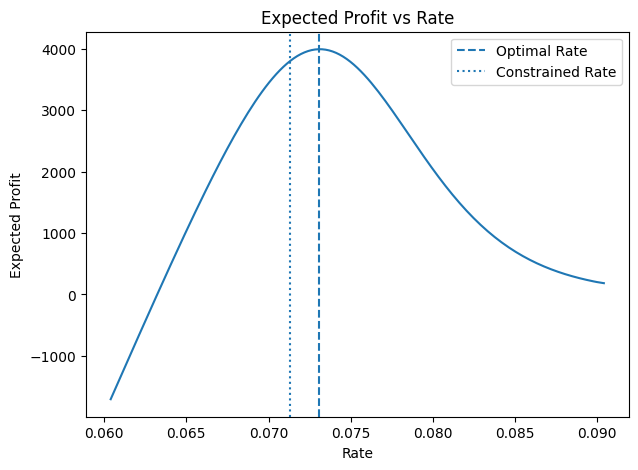

In [94]:
# ------------------------------------------------------------
# 10. PLOT 1: PROFIT VS RATE (CRITICAL)
# ------------------------------------------------------------

row = sample_df.iloc[0]
opt_r, cons_r, _, rates, profits = optimize_rate(row)

plt.figure(figsize=(7,5))
plt.plot(rates, profits)
plt.axvline(opt_r, linestyle="--", label="Optimal Rate")
plt.axvline(cons_r, linestyle=":", label="Constrained Rate")
plt.xlabel("Rate")
plt.ylabel("Expected Profit")
plt.title("Expected Profit vs Rate")
plt.legend()
plt.savefig("profit_vs_rate.png")
plt.show()

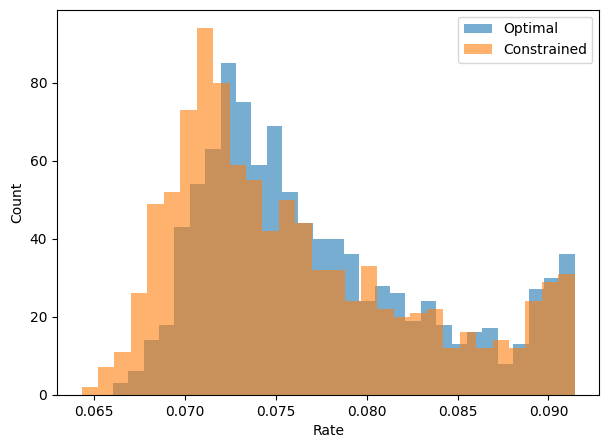

In [98]:
# ------------------------------------------------------------
# 11. PLOT 2: DISTRIBUTION SHIFT (VERY IMPORTANT)
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
plt.hist(opt_rates, bins=30, alpha=0.6, label="Optimal")
plt.hist(cons_rates, bins=30, alpha=0.6, label="Constrained")
plt.xlabel("Rate")
plt.ylabel("Count")
# plt.title("Rate Distribution Shift")
plt.legend()
plt.savefig("rate_distribution.png")
plt.show()

In [96]:
# # ------------------------------------------------------------
# # PLOT: PROFIT VS RATE FOR ALL SAMPLE APPLICATIONS
# # ------------------------------------------------------------

all_profit_curves = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    _, _, _, rates, profits = optimize_rate(row)
    all_profit_curves.append(profits)

all_profit_curves = np.array(all_profit_curves)

mean_profit = all_profit_curves.mean(axis=0)
p25_profit = np.percentile(all_profit_curves, 25, axis=0)
p75_profit = np.percentile(all_profit_curves, 75, axis=0)

# plt.figure(figsize=(8, 5))

# # faint individual curves
# for profits in all_profit_curves[:1000]:
#     plt.plot(rates, profits, alpha=0.03, linewidth=0.7)

# # average curve
# plt.plot(rates, mean_profit, linewidth=3, label="Average Expected Profit")

# # interquartile band
# plt.fill_between(rates, p25_profit, p75_profit, alpha=0.2, label="25th–75th Percentile")

# plt.xlabel("Mortgage Rate")
# plt.ylabel("Expected Profit")
# plt.title("Expected Profit vs Rate Across 1,000 Applications")
# plt.legend()
# plt.tight_layout()
# plt.savefig("profit_vs_rate_all_samples.png", dpi=300)
# plt.show()

100%|██████████| 1000/1000 [19:52<00:00,  1.19s/it]


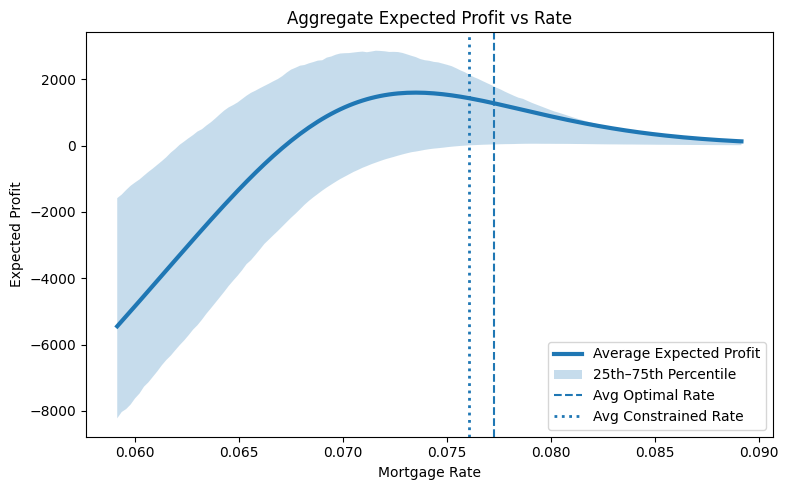

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(rates, mean_profit, linewidth=3, label="Average Expected Profit")
plt.fill_between(rates, p25_profit, p75_profit, alpha=0.25, label="25th–75th Percentile")

# vertical lines
opt_rate_mean = np.mean(opt_rates)
cons_rate_mean = np.mean(cons_rates)

plt.axvline(opt_rate_mean, linestyle="--", linewidth=1.5, label="Avg Optimal Rate")
plt.axvline(cons_rate_mean, linestyle=":", linewidth=2, label="Avg Constrained Rate")

plt.xlabel("Mortgage Rate")
plt.ylabel("Expected Profit")
plt.title("Aggregate Expected Profit vs Rate")

plt.legend()
plt.tight_layout()
plt.show()